In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Tải dữ liệu
df = pd.read_csv("data/tl8.csv")

print("Kích thước dữ liệu gốc:", df.shape)
print("\nPhân phối các nhãn tấn công:")
print(df['attack_label'].value_counts())

Kích thước dữ liệu gốc: (1013, 26)

Phân phối các nhãn tấn công:
attack_label
normal           710
dos_udp_flood    222
grey_hole         81
Name: count, dtype: int64


In [5]:
# Cột không mang giá trị huấn luyện hành vi
cols_to_drop = [
    'window_id', 'time_s', 'flow_id', 'srcNode', 'dstNode',
    'tier', 'srcIp', 'dstIp', 'srcPort', 'dstPort'
]

# Chỉ drop những cột thực sự tồn tại trong file để tránh lỗi
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_cleaned = df.drop(columns=cols_to_drop)

# Xử lý giá trị thiếu (nếu có)
df_cleaned = df_cleaned.fillna(0)

print("Kích thước sau khi làm sạch:", df_cleaned.shape)
print("Các cột đặc trưng còn lại dùng để huấn luyện:")
print(df_cleaned.columns.tolist())

Kích thước sau khi làm sạch: (1013, 16)
Các cột đặc trưng còn lại dùng để huấn luyện:
['txPackets', 'rxPackets', 'txBytes', 'rxBytes', 'lostPackets', 'throughput_bps', 'delay_ms', 'jitter_ms', 'pdr', 'plr', 'x', 'y', 'z', 'speed', 'neighbors', 'attack_label']


In [6]:
# Tách Features (X) và Label (y)
X = df_cleaned.drop(columns=['attack_label'])
y_raw = df_cleaned['attack_label']

# Mã hóa chuỗi nhãn tấn công thành số nguyên (0, 1, 2...)
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Quy tắc mã hóa nhãn (Classes mapping):")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Quy tắc mã hóa nhãn (Classes mapping):
{'dos_udp_flood': np.int64(0), 'grey_hole': np.int64(1), 'normal': np.int64(2)}


In [7]:
# Cắt 20% dữ liệu sang tập test một cách ngẫu nhiên và độc lập
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập Train (X_train):", X_train.shape)
print("Kích thước tập Test (X_test) :", X_test.shape)

Kích thước tập Train (X_train): (810, 15)
Kích thước tập Test (X_test) : (203, 15)


In [9]:
# Cấu hình mô hình Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100000,          # Số lượng cây
    max_depth=20,              # Giới hạn độ sâu để chống overfitting
    min_samples_split=5,       # Mẫu tối thiểu để rẽ nhánh
    class_weight='balanced',   # Tự động điều chỉnh trọng số cân bằng lớp
    random_state=42,
    n_jobs=-1                  # Dùng toàn bộ nhân CPU để tăng tốc
)

# Tiến hành huấn luyện
print("Đang huấn luyện mô hình...")
rf_model.fit(X_train, y_train)
print("Huấn luyện hoàn tất!")

Đang huấn luyện mô hình...
Huấn luyện hoàn tất!


=== BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ===

               precision    recall  f1-score   support

dos_udp_flood       1.00      0.98      0.99        45
    grey_hole       1.00      1.00      1.00        16
       normal       0.99      1.00      1.00       142

     accuracy                           1.00       203
    macro avg       1.00      0.99      1.00       203
 weighted avg       1.00      1.00      1.00       203

=== MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ===


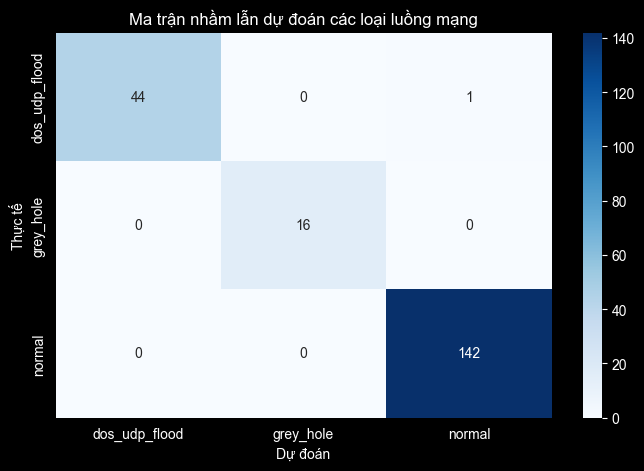

In [10]:
# Dự đoán trên tập dữ liệu chưa từng thấy (X_test)
y_pred = rf_model.predict(X_test)

print("=== BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ===\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("=== MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ===")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

# Vẽ biểu đồ Heatmap cho Confusion Matrix
plt.figure(figsize=(8, 5))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.title('Ma trận nhầm lẫn dự đoán các loại luồng mạng')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

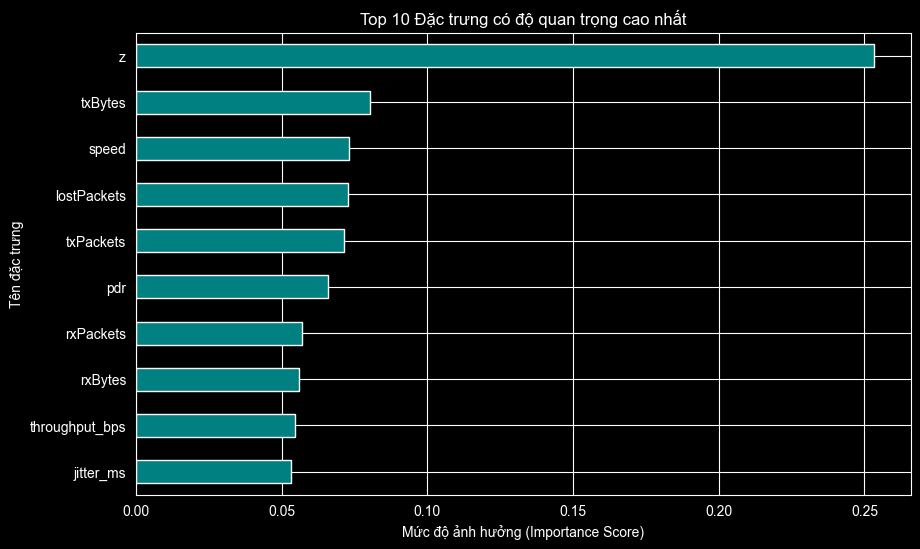

In [11]:
# Vẽ biểu đồ 10 tính năng (features) quan trọng nhất
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Đặc trưng có độ quan trọng cao nhất')
plt.xlabel('Mức độ ảnh hưởng (Importance Score)')
plt.ylabel('Tên đặc trưng')
plt.show()

In [ ]:
# # =====================================================
# # 8. DỰ ĐOÁN
# # =====================================================
#
# y_pred = rf.predict(X_test)
#
# # =====================================================
# # 9. ĐÁNH GIÁ
# # =====================================================
#
# accuracy = accuracy_score(
#     y_test,
#     y_pred
# )
#
# print("\nAccuracy:")
# print(accuracy)
#
# print("\nClassification Report:")
# print(
#     classification_report(
#         y_test,
#         y_pred,
#         target_names=label_encoder.classes_
#     )
# )
#
# print("\nConfusion Matrix:")
# print(
#     confusion_matrix(
#         y_test,
#         y_pred
#     )
# )

In [ ]:
# # =====================================================
# # 10. FEATURE IMPORTANCE
# # =====================================================
#
# importance = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Importance': rf.feature_importances_
# })
#
# importance = importance.sort_values(
#     by='Importance',
#     ascending=False
# )
# #
# print("\nTop 20 Features:")
# print(importance.head(20))

In [ ]:
# train_pred = rf.predict(X_train)
# test_pred = rf.predict(X_test)
#
# print("Train:",
#       accuracy_score(y_train, train_pred))
#
# print("Test:",
#       accuracy_score(y_test, test_pred))